# `03_model_experiments.ipynb` — Updated Skeleton

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# --- Load processed dataset ---
df = pd.read_csv("../data/processed/processed_data.csv")
print("Processed shape:", df.shape)
df.head()


Processed shape: (1449863, 17)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour_of_day,day_of_week,is_weekend,trip_distance_km,rush_hour,weather
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,0,1.498521,1,cloudy
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,1,1.805507,0,sunny
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,0,6.385098,0,cloudy
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,0,1.485498,1,cloudy
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,1,1.188588,0,sunny


## Train/Test Split

In [3]:
X = df[['hour_of_day', 'day_of_week', 'is_weekend',
        'trip_distance_km', 'rush_hour'] + 
        [col for col in df.columns if col.startswith('weather_')]]
y = df['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## MLflow Setup

In [4]:
mlflow.set_tracking_uri("sqlite:///../logs/mlflow.db")
mlflow.set_experiment("ModelExperiments")


2026/08/23 20:35:52 INFO mlflow.tracking.fluent: Experiment with name 'ModelExperiments' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Applications/Venkatesh/Bits/miniProject/Ride-ETA-Prediction/notebooks/mlruns/4', creation_time=1787497552126, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1787497552126, lifecycle_stage='active', name='ModelExperiments', tags={}, trace_location=None, workspace='default'>

## Linear Regression Run

2026/08/23 20:36:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


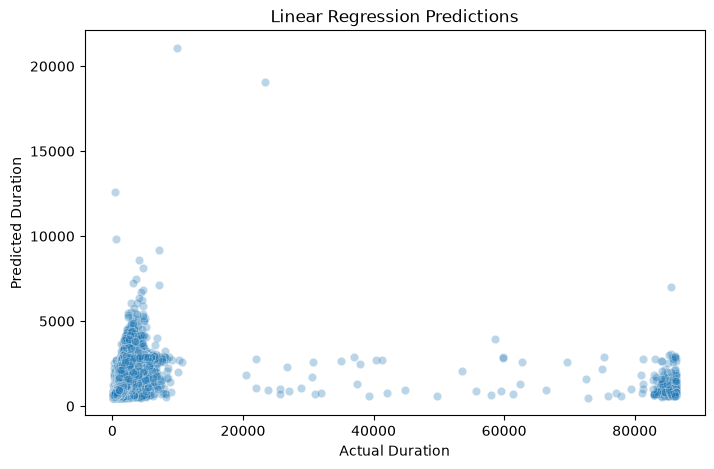

In [5]:
with mlflow.start_run(run_name="Notebook_LinearRegression"):
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    y_pred_lr = lin_reg.predict(X_test)

    lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    lr_r2 = r2_score(y_test, y_pred_lr)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("rmse", lr_rmse)
    mlflow.log_metric("r2", lr_r2)
    mlflow.sklearn.log_model(lin_reg, "linear_regression_model")

    # Save artifact: prediction scatter
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.3)
    plt.xlabel("Actual Duration")
    plt.ylabel("Predicted Duration")
    plt.title("Linear Regression Predictions")
    plot_path = "../logs/lr_predictions_notebook.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path, artifact_path="plots")


## XGBoost Run

2026/08/23 20:36:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


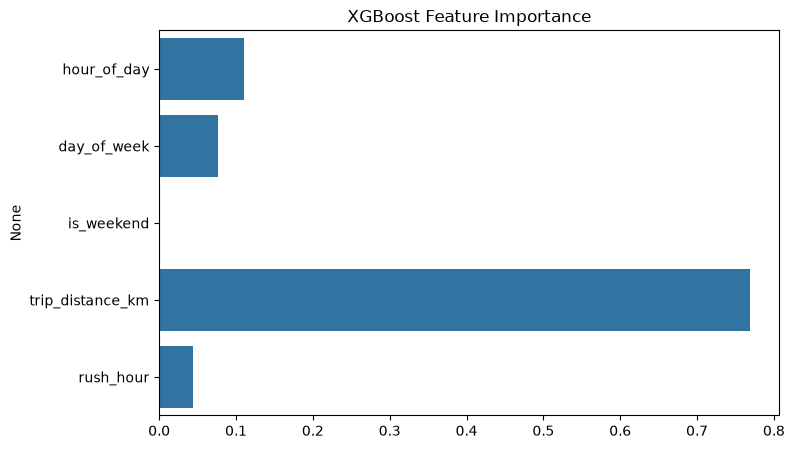

In [6]:
with mlflow.start_run(run_name="Notebook_XGBoost"):
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_r2 = r2_score(y_test, y_pred_xgb)

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("rmse", xgb_rmse)
    mlflow.log_metric("r2", xgb_r2)
    mlflow.xgboost.log_model(xgb, "xgboost_model")

    # Save artifact: feature importance plot
    plt.figure(figsize=(8,5))
    sns.barplot(x=xgb.feature_importances_, y=X.columns)
    plt.title("XGBoost Feature Importance")
    plot_path = "../logs/xgb_feature_importance_notebook.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path, artifact_path="plots")


## Compare Results

In [7]:
print("Linear Regression RMSE:", lr_rmse, "R²:", lr_r2)
print("XGBoost RMSE:", xgb_rmse, "R²:", xgb_r2)

if xgb_rmse < lr_rmse:
    joblib.dump(xgb, "../models/best_model_notebook.pkl")
    print("✅ Best model (XGBoost) saved to ../models/best_model_notebook.pkl")
else:
    joblib.dump(lin_reg, "../models/best_model_notebook.pkl")
    print("✅ Best model (Linear Regression) saved to ../models/best_model_notebook.pkl")


Linear Regression RMSE: 3222.0897529827885 R²: 0.02567661024439505
XGBoost RMSE: 3214.287634920061 R²: 0.030389368534088135
✅ Best model (XGBoost) saved to ../models/best_model_notebook.pkl
